## Part 3: Track Geometry and Path Visualization
To better understand the physical characteristics of the circuits we are analyzing, we will map the x and y coordinates from the telemetry data. This allows us to visualize the exact racing line the drivers take. Note that for certain tracks (like Monza, Spa, and Suzuka), we apply mathematical rotation matrices to align the tracks correctly according to their real-world geographical orientation.

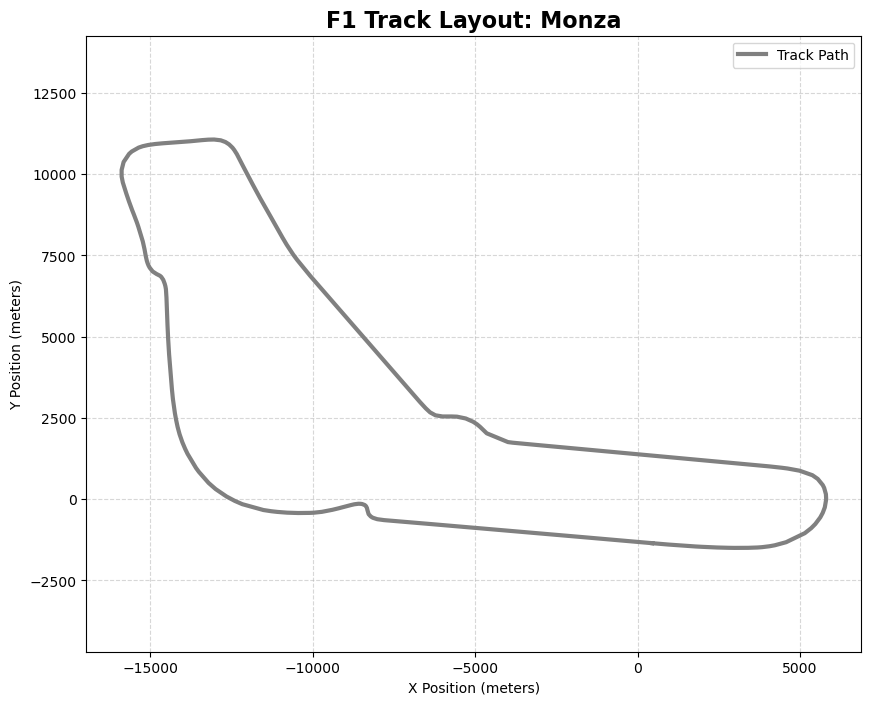

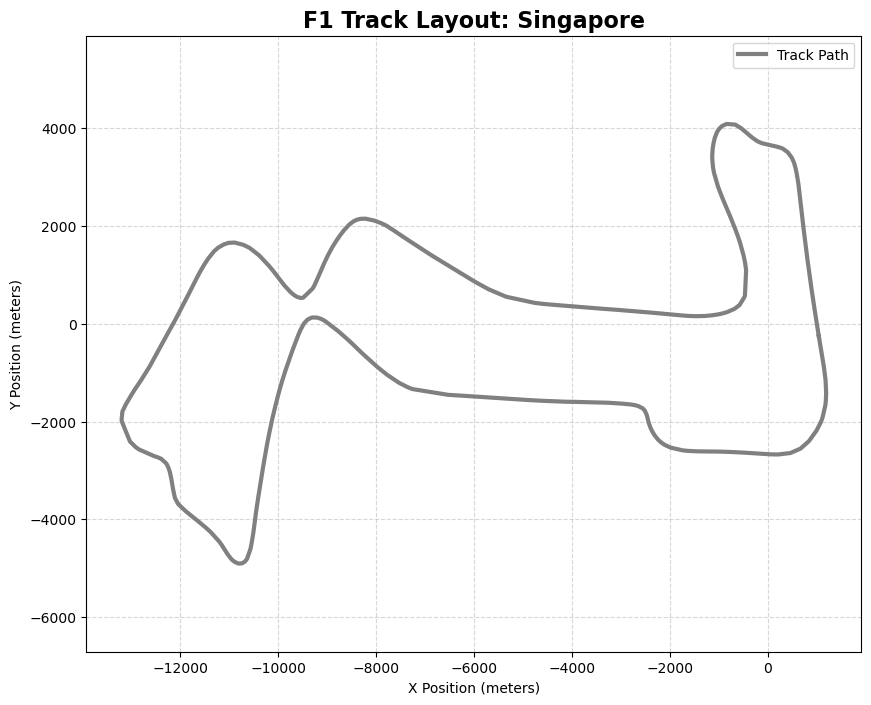

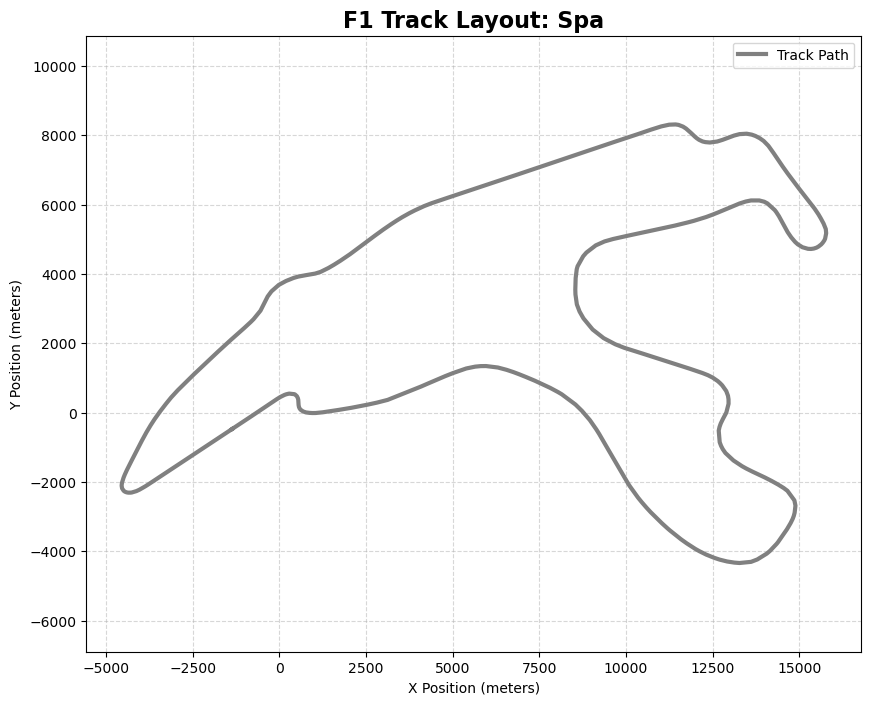

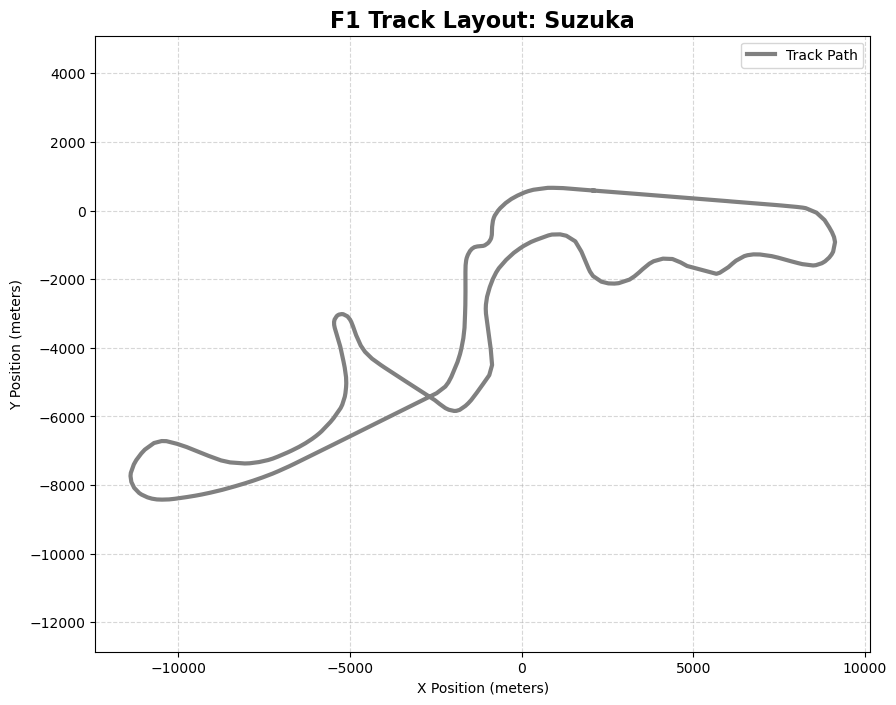

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_f1_track(track_name, file_path='../processed_data/golden_laps_final.csv'):
    
    if not os.path.exists(file_path):
        print(f"[!] Error: File not found at {file_path}")
        return

    df = pd.read_csv(file_path)
    track_data = df[df['Track'] == track_name]
    
    if track_data.empty:
        print(f"[!] No data found for track: {track_name}")
        return

    first_driver = track_data['driver_number'].iloc[0]
    single_lap = track_data[track_data['driver_number'] == first_driver].copy()

    single_lap['x'] = pd.to_numeric(single_lap['x'], errors='coerce')
    single_lap['y'] = pd.to_numeric(single_lap['y'], errors='coerce')
    single_lap = single_lap.dropna(subset=['x', 'y'])

    # Close the gap at the finish line
    single_lap = pd.concat([single_lap, single_lap.iloc[[0]]], ignore_index=True)

    # --- ROTATION LOGIC ---
    if track_name in ['Monza', 'Spa']:
        temp_x = single_lap['x'].copy()
        single_lap['x'] = -single_lap['y']
        single_lap['y'] = temp_x
        
    elif track_name == 'Suzuka':
        angle_degrees = 45 
        theta = np.radians(angle_degrees)
        c = np.cos(theta)
        s = np.sin(theta)
        
        temp_x = single_lap['x'].copy()
        temp_y = single_lap['y'].copy()
        single_lap['x'] = temp_x * c - temp_y * s
        single_lap['y'] = temp_x * s + temp_y * c

    plt.figure(figsize=(10, 8))
    plt.plot(single_lap['x'], single_lap['y'], color='gray', linewidth=3, label='Track Path')
    
    plt.title(f"F1 Track Layout: {track_name}", fontsize=16, fontweight='bold')
    plt.xlabel("X Position (meters)")
    plt.ylabel("Y Position (meters)")

    plt.axis('equal') 
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Print the track layout for each track
tracks_to_plot = ['Monza', 'Singapore', 'Spa', 'Suzuka']
for track in tracks_to_plot:
    plot_f1_track(track)